# Morphological Graphs from Overture Maps and OpenStreetMap with City2Graph

This notebook walks through how to build a morphological graph with `city2graph` using Overture Maps data, with an OpenStreetMap comparison at the end.

## What is a morphological graph?

A morphological graph is a heterogeneous graph where:
- Nodes represent both public space (street segments) and private space (enclosed tessellated areas).
- Edges represent three spatial relationships:
  - Private-to-private: neighboring private spaces
  - Public-to-public: connectivity in the street network (dual graph)
  - Private-to-public: interfaces between private spaces and streets

## Workflow

1. Load building and street data
2. Clean and prepare spatial inputs
3. Build the morphological graph
4. Convert to graph ML formats
5. Visualize and inspect results

## 1. Setup and Dependencies

In [1]:
# Core libraries
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
from shapely import Point

# city2graph for morphological graph analysis
import city2graph as c2g

# Configure matplotlib for high-quality visualizations
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.style.use('ggplot')

print("Dependencies loaded successfully")
print(f"city2graph version: {c2g.__version__}")
print(f"geopandas version: {gpd.__version__}")

Dependencies loaded successfully
city2graph version: 0.3.0
geopandas version: 1.1.3


## 2. Load Data from Overture Maps

We'll use Liverpool city-centre data from Overture Maps:
- Building footprints (private space)
- Road segments (public network)
- Connectors (network junction points)

This gives us a realistic urban sample for building and testing morphological graphs.

In [2]:
# Download data from Overture Maps (uncomment to download fresh data)
c2g.load_overture_data(
    place_name="Liverpool, UK",
    types=["segment", "building", "connector"],
    output_dir="./data/overturemaps",
    prefix="liverpool_",
    save_to_file=True,
    return_data=False,
)

{}

In [3]:
# Load the downloaded GeoJSON files
buildings_gdf = gpd.read_file("./data/overturemaps/liverpool_building.geojson")
segments_gdf = gpd.read_file("./data/overturemaps/liverpool_segment.geojson") 
connectors_gdf = gpd.read_file("./data/overturemaps/liverpool_connector.geojson")

# Convert to British National Grid (EPSG:27700) for accurate distance calculations
buildings_gdf = buildings_gdf.to_crs(epsg=27700)
segments_gdf = segments_gdf.to_crs(epsg=27700)
connectors_gdf = connectors_gdf.to_crs(epsg=27700)

print("Data loaded successfully")
print("Dataset summary:")
print(f"   - Buildings: {len(buildings_gdf):,}")
print(f"   - Road segments: {len(segments_gdf):,}")
print(f"   - Connectors: {len(connectors_gdf):,}")
print(f"   - CRS: {buildings_gdf.crs}")

/Users/yutasato/Projects/Liverpool/city2graph/.venv/lib/python3.13/site-packages/geopandas/io/file.py:576: UserWarning: Could not parse column 'subclass_rules' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)
/Users/yutasato/Projects/Liverpool/city2graph/.venv/lib/python3.13/site-packages/geopandas/io/file.py:576: UserWarning: Could not parse column 'width_rules' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


Data loaded successfully
Dataset summary:
   - Buildings: 107,228
   - Road segments: 39,490
   - Connectors: 50,971
   - CRS: EPSG:27700


## 3. Street Network Processing

Before creating morphological graphs, we need to process the raw street data. This involves:

1. **Filtering**: Keep only road segments (exclude pedestrian paths, railways, etc.)
2. **Barrier Processing**: Handle bridges and tunnels to create accurate spatial barriers
3. **Network Cleanup**: Ensure proper connectivity for graph operations

The `barrier_geometry` column will contain the processed geometries that act as spatial barriers for tessellation.

In [4]:
# Filter to keep only road segments (excluding pedestrian paths, railways, etc.)
segments_gdf = segments_gdf[segments_gdf["subtype"] == "road"].copy()

# Process segments to handle bridges/tunnels and create proper spatial barriers
segments_gdf = c2g.process_overture_segments(
    segments_gdf=segments_gdf,
    get_barriers=True,
    connectors_gdf=connectors_gdf
)

print(f"Processed {len(segments_gdf)} road segments")
print("Barrier geometries created for tessellation")

# Check the geometry types in the barrier_geometry column
geometry_types = segments_gdf["barrier_geometry"].geom_type.value_counts()
print("\nBarrier geometry types:")
for geom_type, count in geometry_types.items():
    print(f"   - {geom_type}: {count:,}")

Processed 67567 road segments
Barrier geometries created for tessellation

Barrier geometry types:
   - LineString: 66,486
   - MultiLineString: 573


You can convert these segments to a (homogeneous) graph using the `segments_to_graph` function. Note that this function can be applied for any segments GeoDataFrame, not only for segments derived from OvertureMaps.

In [5]:
segments_G = c2g.segments_to_graph(segments_gdf, as_nx=True)

Removed 14 invalid geometries


<Axes: >

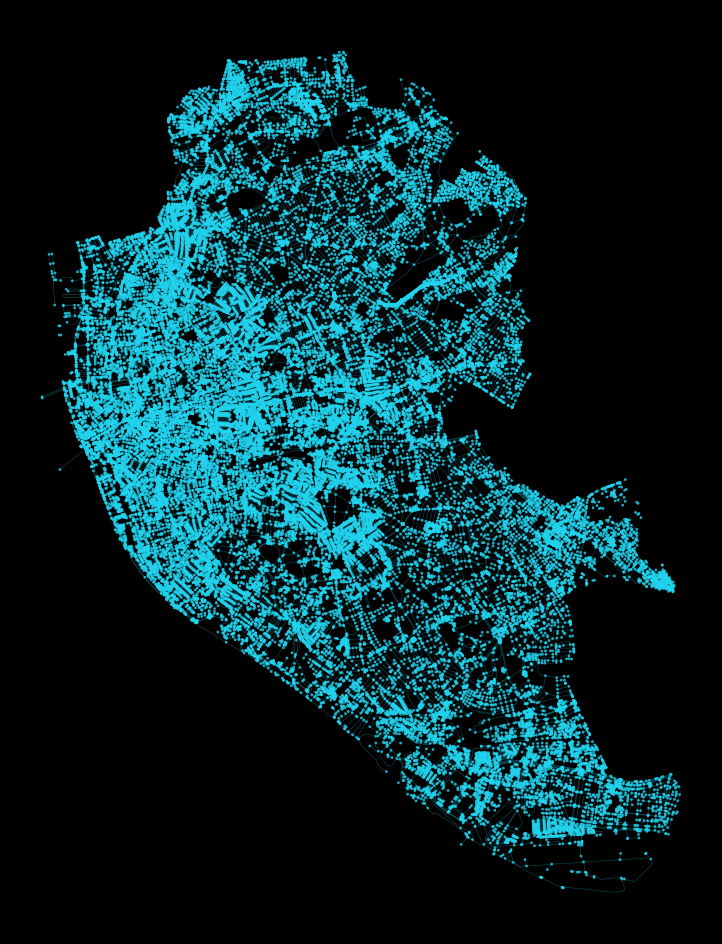

In [6]:
c2g.plot_graph(segments_G)

## 4. Create the Morphological Graph

Now we build the core data structure used in this tutorial.

<div align="center">
    <img src="../assets/figures/morph_net_process.png" alt="Morphological Graph Process" width="800"/>
</div>

### Steps

1. Create tessellations using street segments as barriers
2. Extract spatial relationships
   - Private-to-private: adjacency between private spaces
   - Public-to-public: street-network connectivity
   - Private-to-public: frontage/interface relationships

This gives one unified graph of public and private urban space that you can use for analysis or ML workflows.

In [7]:
# Define center point for the analysis area (Liverpool city centre)
center_point = gpd.GeoSeries([Point(-2.9879004, 53.4062724)], crs='EPSG:4326').to_crs(epsg=27700)

# Create the morphological graph
morpho_nodes, morpho_edges = c2g.morphological_graph(
    buildings_gdf=buildings_gdf,
    segments_gdf=segments_gdf,
    center_point=center_point,
    distance=500,                    # Analysis radius in meters
    clipping_buffer=300,            # Buffer for edge effects
    primary_barrier_col='barrier_geometry',
    contiguity="queen",             # Adjacency rule for tessellation
    keep_buildings=True,            # Preserve building geometries
)

Removed 14 invalid geometries
/Users/yutasato/Projects/Liverpool/city2graph/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 2 islands with ids: 21_21279, 21_21957.
  W.__init__(self, neighbors, ids=ids, **kw)


In [8]:
print(f"Node types: {list(morpho_nodes.keys())}")
print(f"Edge types: {list(morpho_edges.keys())}")
print(f"Private spaces: {len(morpho_nodes['private']):,}")
print(f"Public spaces: {len(morpho_nodes['public']):,}")

for edge_type, edge_gdf in morpho_edges.items():
    print(f"   • {edge_type}: {len(edge_gdf):,} connections")

Node types: ['private', 'public']
Edge types: [('private', 'touched_to', 'private'), ('public', 'connected_to', 'public'), ('private', 'faced_to', 'public')]
Private spaces: 1,337
Public spaces: 802
   • ('private', 'touched_to', 'private'): 613 connections
   • ('public', 'connected_to', 'public'): 1,478 connections
   • ('private', 'faced_to', 'public'): 2,496 connections


In [9]:
morpho_nodes["private"].head()

,geometry,enclosure_index,id,version,sources,level,subtype,class,height,names,...,min_floor,num_floors_underground,roof_material,roof_shape,roof_direction,roof_orientation,roof_color,roof_height,building_geometry,tessellation_geometry
private_id,,,,,,,,,,,,,,,,,,,,,
3_21872,POINT (334873.498 390439.91),3,cfe17f61-252a-4796-b319-3cc062902869,1.0,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,NaN,NaN,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((334801.678 390395.851, 334803.501 39...","POLYGON ((334826.282 390394.268, 334826.121 39..."
3_21872,POINT (334873.498 390439.91),3,76359bbc-484e-4182-b2aa-3f3e2231deda,1.0,"[{'property': '', 'dataset': 'OpenStreetMap', ...",4.0,NaN,NaN,125.0,"{'primary': 'St Johns beacon', 'common': None,...",...,NaN,NaN,NaN,flat,NaN,NaN,#464875,NaN,"POLYGON ((334810.844 390396.615, 334811.403 39...","POLYGON ((334826.282 390394.268, 334826.121 39..."
3_21872,POINT (334873.498 390439.91),3,f5bf15d8-3547-41aa-a9db-abaa10435702,1.0,"[{'property': '', 'dataset': 'OpenStreetMap', ...",3.0,NaN,NaN,110.0,"{'primary': ""Saint John's Beacon"", 'common': N...",...,NaN,NaN,NaN,pyramidal,NaN,NaN,#464875,3.0,"POLYGON ((334804.854 390402.461, 334806.725 39...","POLYGON ((334826.282 390394.268, 334826.121 39..."
3_21872,POINT (334873.498 390439.91),3,806b8ff0-ee54-47f4-af82-fef9069e18cd,1.0,"[{'property': '', 'dataset': 'OpenStreetMap', ...",NaN,entertainment,NaN,NaN,"{'primary': 'The Playhouse', 'common': None, '...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((334782.286 390434.238, 334803.535 39...","POLYGON ((334826.282 390394.268, 334826.121 39..."
3_21872,POINT (334873.498 390439.91),3,e698148b-d3f8-4141-80be-73c252b18114,3.0,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1.0,NaN,NaN,21.0,{'primary': 'Holiday Inn Liverpool City Centre...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((334934.651 390448.532, 334945.788 39...","POLYGON ((334826.282 390394.268, 334826.121 39..."


In [10]:
morpho_nodes["public"].head()

,id,version,sources,subtype,class,names,connectors,routes,subclass_rules,access_restrictions,...,road_flags,speed_limits,width_rules,subclass,geometry,split_from,split_to,length,barrier_geometry,segment_geometry
public_id,,,,,,,,,,,,,,,,,,,,,
5925,e0bde33d-2b9c-4c2d-aa04-a97282b77f3c,1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,footway,"{'primary': 'Silkhouse Lane', 'common': None, ...",[{'connector_id': 'cb80addf-b40f-4a2c-b934-9ea...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,POINT (334150.16 390644.48),NaN,NaN,61.861764,"LINESTRING (334169.374 390620.261, 334163.126 ...","LINESTRING (334169.374 390620.261, 334163.126 ..."
6003,71f65a3f-ac2b-4a9f-965b-7b906e01a02d_2,1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,unclassified,"{'primary': 'George Street', 'common': None, '...",[{'connector_id': 'd1087f24-d203-40be-8755-bc6...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,POINT (334125.974 390664.938),0.401639,0.499762,11.245853,"LINESTRING (334121.486 390661.551, 334121.486 ...","LINESTRING (334121.486 390661.551, 334121.486 ..."
6004,71f65a3f-ac2b-4a9f-965b-7b906e01a02d_3,1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,unclassified,"{'primary': 'George Street', 'common': None, '...",[{'connector_id': 'd1087f24-d203-40be-8755-bc6...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,POINT (334152.375 390686.808),0.499762,1.000000,57.332357,"LINESTRING (334130.463 390668.325, 334130.463 ...","LINESTRING (334130.463 390668.325, 334130.463 ..."
5978,72f5861f-12e2-469b-9a1e-ac1255565df4_2,1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,footway,NaN,[{'connector_id': 'd3c8c209-bc3b-4afb-b781-dbc...,NaN,NaN,NaN,...,"[{'values': ['is_tunnel'], 'between': None}]",NaN,NaN,NaN,POINT (334253.291 390669.572),0.472509,1.000000,4.051704,None,"LINESTRING (334254.06 390667.698, 334252.523 3..."
6006,8875ee79-3883-4dac-820e-178a84e73d32,1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,steps,NaN,[{'connector_id': '9ef168e1-b984-4916-abde-fad...,NaN,NaN,NaN,...,"[{'values': ['is_tunnel'], 'between': None}]",NaN,NaN,NaN,POINT (334248.53 390681.222),NaN,NaN,21.117956,None,"LINESTRING (334252.523 390671.447, 334244.537 ..."


In [11]:
morpho_edges[('public', 'connected_to', 'public')].head()

geometry
from_public_id to_public_id                                                   
3652           3660          LINESTRING (334159.774 390163.587, 334198.911 ...
               4813          LINESTRING (334159.774 390163.587, 334148.816 ...
3653           3654          LINESTRING (334106.02 390173.147, 334109.83 39...
               3658          LINESTRING (334106.02 390173.147, 334115.312 3...
               3673          LINESTRING (334106.02 390173.147, 334095.885 3...

In [12]:
morpho_edges[('private', 'faced_to', 'public')].head()

,,geometry
private_id,public_id,
41_23139,5925,"LINESTRING (334124.632 390556.767, 334150.16 3..."
346_23142,5925,"LINESTRING (334135.097 390624.685, 334150.16 3..."
348_23143,5925,"LINESTRING (334170.822 390641.238, 334150.16 3..."
348_23144,5925,"LINESTRING (334152.116 390657.487, 334150.16 3..."
244_23141,5925,"LINESTRING (334196.481 390627.064, 334150.16 3..."


In [13]:
morpho_edges[('private', 'touched_to', 'private')].head()

weight  \
from_private_id to_private_id               
3_21872         3_21892         32.241903   
                3_21889         94.689168   
                3_21886         74.699474   
                3_21881        101.010127   
                3_21888         62.819823   

                                                                        geometry  \
from_private_id to_private_id                                                      
3_21872         3_21892        LINESTRING (334873.498 390439.91, 334845.529 3...   
                3_21889        LINESTRING (334873.498 390439.91, 334783.071 3...   
                3_21886        LINESTRING (334873.498 390439.91, 334819.742 3...   
                3_21881        LINESTRING (334873.498 390439.91, 334774.745 3...   
                3_21888        LINESTRING (334873.498 390439.91, 334823.576 3...   

                               enclosure_index  
from_private_id to_private_id                   
3_21872         3_21892                      3  
                3_21889                      3  
                3_21886                      3  
                3_21881                      3  
                3_21888                      3

In [14]:
morpho_nodes["public"]

,id,version,sources,subtype,class,names,connectors,routes,subclass_rules,access_restrictions,...,road_flags,speed_limits,width_rules,subclass,geometry,split_from,split_to,length,barrier_geometry,segment_geometry
public_id,,,,,,,,,,,,,,,,,,,,,
5925,e0bde33d-2b9c-4c2d-aa04-a97282b77f3c,1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,footway,"{'primary': 'Silkhouse Lane', 'common': None, ...",[{'connector_id': 'cb80addf-b40f-4a2c-b934-9ea...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,POINT (334150.16 390644.48),NaN,NaN,61.861764,"LINESTRING (334169.374 390620.261, 334163.126 ...","LINESTRING (334169.374 390620.261, 334163.126 ..."
6003,71f65a3f-ac2b-4a9f-965b-7b906e01a02d_2,1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,unclassified,"{'primary': 'George Street', 'common': None, '...",[{'connector_id': 'd1087f24-d203-40be-8755-bc6...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,POINT (334125.974 390664.938),0.401639,0.499762,11.245853,"LINESTRING (334121.486 390661.551, 334121.486 ...","LINESTRING (334121.486 390661.551, 334121.486 ..."
6004,71f65a3f-ac2b-4a9f-965b-7b906e01a02d_3,1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,unclassified,"{'primary': 'George Street', 'common': None, '...",[{'connector_id': 'd1087f24-d203-40be-8755-bc6...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,POINT (334152.375 390686.808),0.499762,1.000000,57.332357,"LINESTRING (334130.463 390668.325, 334130.463 ...","LINESTRING (334130.463 390668.325, 334130.463 ..."
5978,72f5861f-12e2-469b-9a1e-ac1255565df4_2,1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,footway,NaN,[{'connector_id': 'd3c8c209-bc3b-4afb-b781-dbc...,NaN,NaN,NaN,...,"[{'values': ['is_tunnel'], 'between': None}]",NaN,NaN,NaN,POINT (334253.291 390669.572),0.472509,1.000000,4.051704,None,"LINESTRING (334254.06 390667.698, 334252.523 3..."
6006,8875ee79-3883-4dac-820e-178a84e73d32,1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,steps,NaN,[{'connector_id': '9ef168e1-b984-4916-abde-fad...,NaN,NaN,NaN,...,"[{'values': ['is_tunnel'], 'between': None}]",NaN,NaN,NaN,POINT (334248.53 390681.222),NaN,NaN,21.117956,None,"LINESTRING (334252.523 390671.447, 334244.537 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5985,15129c3c-39b0-48f5-a50f-fed638f77c5c_1,1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,footway,NaN,[{'connector_id': 'c8c6db5f-fd5f-4081-8a40-b04...,NaN,NaN,NaN,...,"[{'values': ['is_tunnel'], 'between': None}]",NaN,NaN,NaN,POINT (334311.927 390679.223),0.000000,0.161856,6.072757,None,"LINESTRING (334309.954 390681.532, 334313.9 39..."
5993,fa41a3f0-fbe0-4dd4-8cb7-ca4a0cff5bd1_2,2,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,service,NaN,[{'connector_id': '3396b058-f2f8-4319-985d-2c8...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,POINT (334382.856 390682.399),0.088272,1.000000,7.534685,"LINESTRING (334380.166 390685.037, 334380.416 ...","LINESTRING (334380.166 390685.037, 334380.416 ..."
5996,1b0e7a0c-9d5b-490a-aeed-a1af1cb8829c_1,1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,unclassified,"{'primary': 'Hale Street', 'common': None, 'ru...",[{'connector_id': '5ebb5ed2-a348-407d-b350-9b9...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,POINT (334397.203 390690.514),0.000000,0.606566,31.720834,"LINESTRING (334408.861 390701.268, 334385.545 ...","LINESTRING (334408.861 390701.268, 334385.545 ..."


<Axes: >

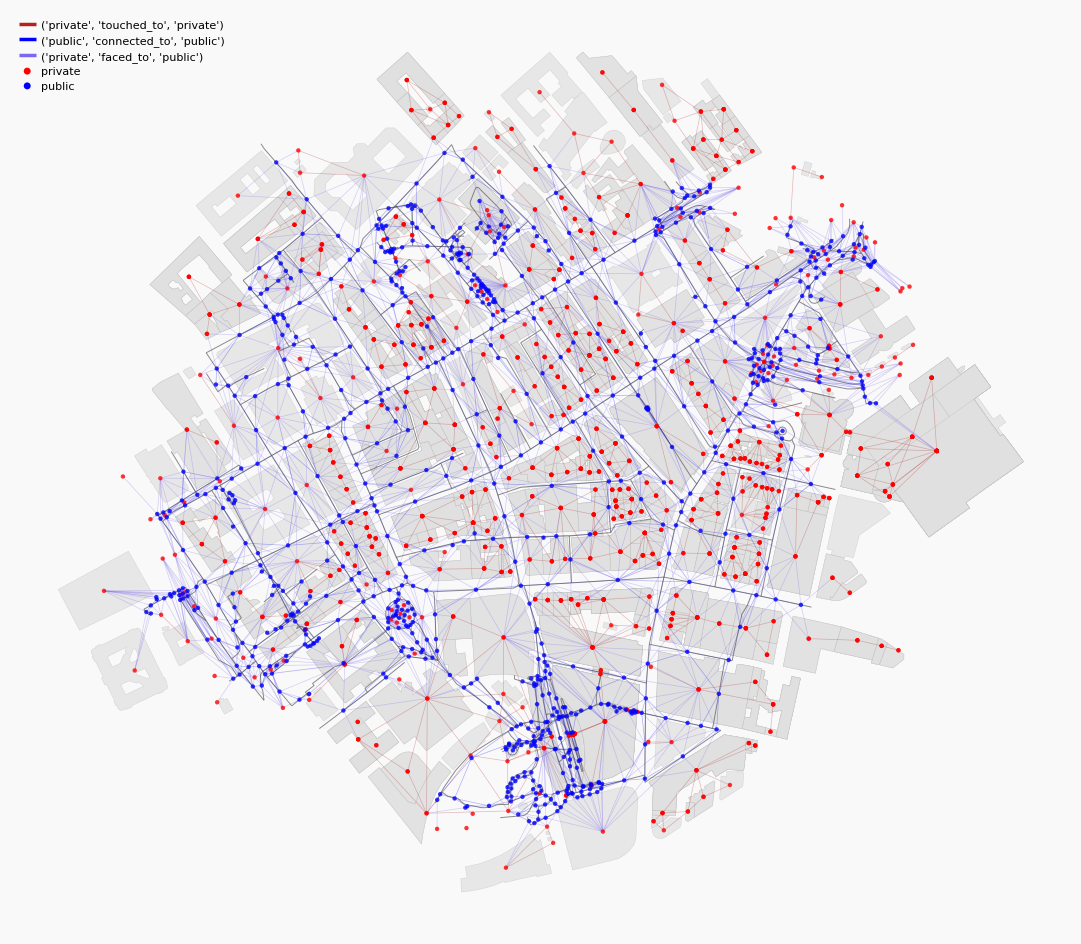

In [15]:
fig, ax = plt.subplots(figsize=(14, 12), facecolor='#f9f9f9')

morpho_nodes["private"]["building_geometry"].plot(ax=ax, color='#e0e0e0', edgecolor='#c0c0c0', linewidth=0.3, alpha=0.7)
morpho_nodes["public"]["segment_geometry"].plot(ax=ax, color='#404040', linewidth=0.7, alpha=0.6)

c2g.plot_graph(
    nodes=morpho_nodes,
    edges=morpho_edges,
    subplots=False,
    ax=ax,
    bgcolor="#f9f9f9",
    labelcolor="#000000",
    node_color={'private': 'red', 'public': 'blue'},
    edge_color={
        ('private', 'touched_to', 'private'): '#B22222',
        ('public', 'connected_to', 'public'): '#0000FF',
        ('private', 'faced_to', 'public'): '#7B68EE',
    },
    markersize=10,
    linewidth=0.2,
)

## 6. Convert to Graph Formats for Machine Learning

City2Graph can move between spatial tables and graph formats used in analysis and ML.

### Supported formats
- NetworkX: general graph analysis
- PyTorch Geometric: graph deep learning
- GeoDataFrames: spatial analysis and plotting

This section shows common conversion patterns and quick checks.

In [16]:
# Check for PyTorch Geometric availability
import torch

try:
    import torch_geometric
    HAS_TORCH_GEOMETRIC = True
    print("PyTorch Geometric imported successfully")
    print(f"   PyTorch version: {torch.__version__}")
    print(f"   PyTorch Geometric version: {torch_geometric.__version__}")
    print("Ready for graph representation learning")
except ImportError:
    HAS_TORCH_GEOMETRIC = False
    print("PyTorch Geometric is not installed")
    print("Install with: pip install torch-geometric")
    print("Graph conversion examples will continue with available backends")

PyTorch Geometric imported successfully
   PyTorch version: 2.10.0
   PyTorch Geometric version: 2.7.0
Ready for graph representation learning


### 6.1 Homogeneous Graph: Private Space Network

Let's start with a homogeneous graph focusing on private spaces (tessellation cells) and their adjacency relationships. This represents the spatial structure of plots and parcels in the urban environment.

In [17]:
# Compute spatial features for private spaces (tessellation cells)
morpho_nodes["private"]["area"] = morpho_nodes["private"].geometry.area
morpho_nodes["private"]["perimeter"] = morpho_nodes["private"].geometry.length
morpho_nodes["private"]["compactness"] = (
    4 * np.pi * morpho_nodes["private"]["area"] / (morpho_nodes["private"]["perimeter"] ** 2)
)

print("Computed spatial features for private spaces:")
feature_stats = morpho_nodes["private"][['area', 'perimeter', 'compactness']].describe()
print(feature_stats.round(2))

# Set proper index names for graph conversion
morpho_nodes["private"].index.name = "tess_id"
morpho_edges[('private', 'touched_to', 'private')].index.names = ['from_private_id', 'to_private_id']

print("\nFeatures computed and indices configured")

Computed spatial features for private spaces:
         area  perimeter  compactness
count  1337.0     1337.0          0.0
mean      0.0        0.0          NaN
std       0.0        0.0          NaN
min       0.0        0.0          NaN
25%       0.0        0.0          NaN
50%       0.0        0.0          NaN
75%       0.0        0.0          NaN
max       0.0        0.0          NaN

Features computed and indices configured


In [18]:
if HAS_TORCH_GEOMETRIC:
    # Create homogeneous graph of private spaces
    private_graph = c2g.gdf_to_pyg(
        nodes=morpho_nodes["private"],
        edges=morpho_edges[('private', 'touched_to', 'private')],
        node_feature_cols=['area', 'perimeter', 'compactness'],
        edge_feature_cols=None
    )
    
    print("Created homogeneous graph:")
    print(f"   - Nodes: {private_graph.num_nodes:,}")
    print(f"   - Edges: {private_graph.num_edges:,}")
    print(f"   - Node features: {private_graph.x.shape[1]} dimensions")
    print(f"   - Feature tensor shape: {private_graph.x.shape}")
    print("\nGraph is ready for training")
    
else:
    print("Skipping PyTorch Geometric conversion (not installed)")
    private_graph = None

Created homogeneous graph:
   - Nodes: 1,337
   - Edges: 613
   - Node features: 3 dimensions
   - Feature tensor shape: torch.Size([1337, 3])

Graph is ready for training


#### Conversion Checks

Now let's run the same pipeline again and build a full heterogeneous graph. This second run is useful for validating that format conversions preserve the expected structure.

In [19]:
# Define center point for the analysis area (Liverpool city centre)
center_point = gpd.GeoSeries([Point(-2.9879004, 53.4062724)], crs='EPSG:4326').to_crs(epsg=27700)

# Create the morphological graph
print("Creating morphological graph...")
morpho_nodes, morpho_edges = c2g.morphological_graph(
    buildings_gdf=buildings_gdf,
    segments_gdf=segments_gdf,
    center_point=center_point,
    distance=500,                    # Analysis radius in meters
    clipping_buffer=300,            # Buffer for edge effects
    primary_barrier_col='barrier_geometry',
    contiguity="queen",             # Adjacency rule for tessellation
    keep_buildings=True,            # Preserve building geometries
)

print("Morphological graph created successfully")
print("Network summary:")
print(f"   - Node types: {list(morpho_nodes.keys())}")
print(f"   - Edge types: {list(morpho_edges.keys())}")
print(f"   - Private spaces: {len(morpho_nodes['private']):,}")
print(f"   - Public spaces: {len(morpho_nodes['public']):,}")

for edge_type, edge_gdf in morpho_edges.items():
    print(f"   - {edge_type}: {len(edge_gdf):,} connections")

Removed 14 invalid geometries


Creating morphological graph...
Morphological graph created successfully
Network summary:
   - Node types: ['private', 'public']
   - Edge types: [('private', 'touched_to', 'private'), ('public', 'connected_to', 'public'), ('private', 'faced_to', 'public')]
   - Private spaces: 1,337
   - Public spaces: 802
   - ('private', 'touched_to', 'private'): 613 connections
   - ('public', 'connected_to', 'public'): 1,478 connections
   - ('private', 'faced_to', 'public'): 2,496 connections


/Users/yutasato/Projects/Liverpool/city2graph/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 2 islands with ids: 21_21279, 21_21957.
  W.__init__(self, neighbors, ids=ids, **kw)


In [20]:
# Recompute node features after rebuilding morpho_nodes
morpho_nodes["private"]["area"] = morpho_nodes["private"].geometry.area
morpho_nodes["private"]["perimeter"] = morpho_nodes["private"].geometry.length
morpho_nodes["private"]["compactness"] = (
    4 * np.pi * morpho_nodes["private"]["area"] / (morpho_nodes["private"]["perimeter"] ** 2)
)
morpho_nodes["public"]["length"] = morpho_nodes["public"].geometry.length

# Keep index names explicit so downstream conversions preserve structure
morpho_nodes["private"].index.name = "private_id"
morpho_nodes["public"].index.name = "public_id"
morpho_edges[('private', 'touched_to', 'private')].index.names = ['from_private_id', 'to_private_id']
morpho_edges[('public', 'connected_to', 'public')].index.names = ['from_public_id', 'to_public_id']
morpho_edges[('private', 'faced_to', 'public')].index.names = ['from_private_id', 'to_public_id']

print("Computed spatial features for private and public nodes")
print("Private feature columns:", ["area", "perimeter", "compactness"])
print("Public feature columns:", ["length"])

Computed spatial features for private and public nodes
Private feature columns: ['area', 'perimeter', 'compactness']
Public feature columns: ['length']


In [21]:
if HAS_TORCH_GEOMETRIC:
    # Create heterogeneous graph with all morphological relationships
    hetero_graph = c2g.gdf_to_pyg(
        morpho_nodes,
        morpho_edges,
        node_feature_cols={
            "private": ['area', 'perimeter', 'compactness'],
            "public": ['length']
        }
    )
    
    print("Created heterogeneous morphological graph:")
    print("Node types and counts:")
    for node_type in hetero_graph.node_types:
        num_nodes = hetero_graph[node_type].x.shape[0]
        num_features = hetero_graph[node_type].x.shape[1]
        print(f"   - {node_type}: {num_nodes:,} nodes, {num_features} features")
    
    print("Edge types and counts:")
    for edge_type in hetero_graph.edge_types:
        num_edges = hetero_graph[edge_type].edge_index.shape[1]
        print(f"   - {edge_type}: {num_edges:,} edges")
    
    print("\nComplete morphological graph is ready for heterogeneous GNN workflows")
    
else:
    print("Skipping PyTorch Geometric conversion (not installed)")
    hetero_graph = None

Created heterogeneous morphological graph:
Node types and counts:
   - private: 1,337 nodes, 3 features
   - public: 802 nodes, 1 features
Edge types and counts:
   - ('private', 'touched_to', 'private'): 613 edges
   - ('public', 'connected_to', 'public'): 1,478 edges
   - ('private', 'faced_to', 'public'): 2,496 edges

Complete morphological graph is ready for heterogeneous GNN workflows


In [22]:
hetero_graph

HeteroData(
  crs=EPSG:27700,
  graph_metadata=<city2graph.base.GraphMetadata object at 0x13392baf0>,
  private={
    x=[1337, 3],
    pos=[1337, 2],
  },
  public={
    x=[802, 1],
    pos=[802, 2],
  },
  (private, touched_to, private)={
    edge_index=[2, 613],
    edge_attr=[613, 0],
  },
  (public, connected_to, public)={
    edge_index=[2, 1478],
    edge_attr=[1478, 0],
  },
  (private, faced_to, public)={
    edge_index=[2, 2496],
    edge_attr=[2496, 0],
  }
)

### 6.3 Using NetworkX

City2Graph provides seamless conversion to NetworkX for traditional graph analysis and algorithms. This enables access to the rich ecosystem of graph analysis tools.

In [23]:
# Convert morphological graph to PyG and NetworkX
morpho_graph = c2g.gdf_to_pyg(
    morpho_nodes,
    morpho_edges,
    node_feature_cols={
        "private": ['area', 'perimeter', 'compactness'],
        "public": ['length']
    },
)

# Convert morphological graph to NetworkX for traditional graph analysis
G_morpho = c2g.gdf_to_nx(morpho_nodes, morpho_edges, keep_geom=True)

print("Converted to NetworkX:")
print(f"   - Total nodes: {G_morpho.number_of_nodes():,}")
print(f"   - Total edges: {G_morpho.number_of_edges():,}")
print(f"   - Graph type: {'Directed' if G_morpho.is_directed() else 'Undirected'}")

# Check heterogeneity and inspect attributes
has_node_types = any('node_type' in data for _, data in G_morpho.nodes(data=True))
print(f"   - Heterogeneous: {'Yes' if has_node_types else 'No'}")

sample_node_id, sample_node_data = next(iter(G_morpho.nodes(data=True)))
non_private_keys = [k for k in sample_node_data.keys() if not k.startswith('_')]
print(f"   - Sample node id: {sample_node_id}")
print(f"   - Sample node attributes: {non_private_keys}")

if has_node_types:
    from collections import Counter

    node_types = [data.get('node_type', 'unknown') for _, data in G_morpho.nodes(data=True)]
    type_counts = Counter(node_types)
    print("   - Node type distribution:")
    for node_type, count in type_counts.items():
        print(f"     - {node_type}: {count:,}")

print("\nNetworkX graph is ready for analysis")

Converted to NetworkX:
   - Total nodes: 2,139
   - Total edges: 4,587
   - Graph type: Undirected
   - Heterogeneous: Yes
   - Sample node id: 0
   - Sample node attributes: ['geometry', 'enclosure_index', 'id', 'version', 'sources', 'level', 'subtype', 'class', 'height', 'names', 'has_parts', 'is_underground', 'min_height', 'num_floors', 'facade_color', 'facade_material', 'min_floor', 'num_floors_underground', 'roof_material', 'roof_shape', 'roof_direction', 'roof_orientation', 'roof_color', 'roof_height', 'building_geometry', 'tessellation_geometry', 'area', 'perimeter', 'compactness', 'node_type', 'pos']
   - Node type distribution:
     - private: 1,337
     - public: 802

NetworkX graph is ready for analysis


## 7. OpenStreetMap

For comparison, you can run the same workflow with data pulled from OpenStreetMap using `osmnx`.

In [24]:
import osmnx as ox

# Download and create a street network graph for Liverpool, UK
G_osmnx = ox.graph_from_place("Liverpool, UK", network_type="all")

print("OSMnx graph created for Liverpool, UK")
print(f"   - Nodes: {len(G_osmnx.nodes):,}")
print(f"   - Edges: {len(G_osmnx.edges):,}")

OSMnx graph created for Liverpool, UK
   - Nodes: 45,081
   - Edges: 114,978


In [25]:
# Download POIs (amenities, shops, etc.) in Liverpool, UK
tags = {"building": True}
osm_buildings = ox.features_from_place("Liverpool, UK", tags)

print(f"Retrieved {len(osm_buildings):,} buildings from OSMnx")
osm_buildings.head()

Retrieved 77,492 buildings from OSMnx


geometry     building building:material  \
element id                                                                     
node    130190976   POINT (-2.92799 53.37127)          yes             brick   
        252558860     POINT (-2.91785 53.396)  residential               NaN   
        299317179   POINT (-2.97904 53.39175)          yes               NaN   
        1563152870  POINT (-2.91166 53.41248)  manufacture               NaN   
        1669223582  POINT (-2.96855 53.40601)          yes               NaN   

                   building:use                              name  \
element id                                                          
node    130190976     religious   Saint Anne's Parish Hall - 1902   
        252558860           NaN                    Bradbury House   
        299317179           NaN         Toxteth Ambulance Station   
        1563152870          NaN         Tom Williams Cake Factory   
        1669223582          NaN  ALL (Active Learning Laboratory)   

                            emergency       addr:street    shop  \
element id                                                        
node    130190976                 NaN               NaN     NaN   
        252558860                 NaN               NaN     NaN   
        299317179   ambulance_station               NaN     NaN   
        1563152870                NaN  Broad Green Road  pastry   
        1669223582                NaN               NaN     NaN   

                                          website addr:city  ...  \
element id                                                   ...   
node    130190976                             NaN       NaN  ...   
        252558860                             NaN       NaN  ...   
        299317179                             NaN       NaN  ...   
        1563152870  http://www.cakefactory.co.uk/       NaN  ...   
        1669223582                            NaN       NaN  ...   

                   service:bicycle:parts service:bicycle:pump  \
element id                                                      
node    130190976                    NaN                  NaN   
        252558860                    NaN                  NaN   
        299317179                    NaN                  NaN   
        1563152870                   NaN                  NaN   
        1669223582                   NaN                  NaN   

                   service:bicycle:second_hand service:bicycle:spare_parts  \
element id                                                                   
node    130190976                          NaN                         NaN   
        252558860                          NaN                         NaN   
        299317179                          NaN                         NaN   
        1563152870                         NaN                         NaN   
        1669223582                         NaN                         NaN   

                   type school:trust school:trust:name school:trust:type  \
element id                                                                 
node    130190976   NaN          NaN               NaN               NaN   
        252558860   NaN          NaN               NaN               NaN   
        299317179   NaN          NaN               NaN               NaN   
        1563152870  NaN          NaN               NaN               NaN   
        1669223582  NaN          NaN               NaN               NaN   

                   manager last_checked  
element id                               
node    130190976      NaN          NaN  
        252558860      NaN          NaN  
        299317179      NaN          NaN  
        1563152870     NaN          NaN  
        1669223582     NaN          NaN  

[5 rows x 378 columns]

If you want to directly convert the `nx.MultiGraph` into `torch_geometric.data.Data`,

In [26]:
osm_data = c2g.nx_to_pyg(G_osmnx)

In [27]:
osm_data

Data(x=[45081, 0], edge_index=[2, 114978], edge_attr=[114978, 0], pos=[45081, 2], graph_metadata=<city2graph.base.GraphMetadata object at 0x133cac050>)

Or you can convert it into `GeoDataFrame` that is compatible to other functions in `City2Graph`, 

In [28]:
osm_street_nodes, osm_street_edges =c2g.nx_to_gdf(G_osmnx)

In [29]:
osm_street_nodes.head()

,y,x,street_count,geometry,highway,ref,junction
324206,53.407123,-2.884331,3,POINT (-2.88433 53.40712),NaN,NaN,NaN
324209,53.405943,-2.896571,3,POINT (-2.89657 53.40594),NaN,NaN,NaN
324210,53.406113,-2.896688,3,POINT (-2.89669 53.40611),motorway_junction,4,NaN
324216,53.406488,-2.899987,3,POINT (-2.89999 53.40649),NaN,NaN,NaN
324217,53.407391,-2.902198,3,POINT (-2.9022 53.40739),NaN,NaN,NaN


In [30]:
osm_street_edges.head()

osmid  \
324206 324209      0  [28181793, 627409058, 546631471, 1155945617, 1...   
324209 3467956864  0                                           15215646   
324210 11385898804 0                                           15215652   
324216 21026685    0                                            4002276   
       21026680    0                                            4002284   

                         highway lanes                  maxspeed  oneway  \
324206 324209      0    motorway     3  [70 mph, 40 mph, 50 mph]    True   
324209 3467956864  0       trunk     3                    40 mph    True   
324210 11385898804 0     primary   NaN                    40 mph    True   
324216 21026685    0       trunk     3                    40 mph    True   
       21026680    0  trunk_link   NaN                    40 mph    True   

                        ref reversed      length bridge  \
324206 324209      0    M62    False  823.913652    yes   
324209 3467956864  0  A5080    False   52.584979    NaN   
324210 11385898804 0  A5080    False   32.304470    NaN   
324216 21026685    0  A5080    False   87.887476    NaN   
       21026680    0    NaN    False   61.909425    NaN   

                                                               geometry  \
324206 324209      0  LINESTRING (-2.88433 53.40712, -2.88494 53.407...   
324209 3467956864  0  LINESTRING (-2.89657 53.40594, -2.89678 53.405...   
324210 11385898804 0  LINESTRING (-2.89669 53.40611, -2.89629 53.406...   
324216 21026685    0  LINESTRING (-2.89999 53.40649, -2.90028 53.406...   
       21026680    0  LINESTRING (-2.89999 53.40649, -2.90029 53.406...   

                                   name junction service access width tunnel  \
324206 324209      0                NaN      NaN     NaN    NaN   NaN    NaN   
324209 3467956864  0  Bowring Park Road      NaN     NaN    NaN   NaN    NaN   
324210 11385898804 0  Bowring Park Road      NaN     NaN    NaN   NaN    NaN   
324216 21026685    0    Edge Lane Drive      NaN     NaN    NaN   NaN    NaN   
       21026680    0                NaN      NaN     NaN    NaN   NaN    NaN   

                     est_width  
324206 324209      0       NaN  
324209 3467956864  0       NaN  
324210 11385898804 0       NaN  
324216 21026685    0       NaN  
       21026680    0       NaN

To construct a morphological graph:

In [31]:
osm_buildings = osm_buildings.to_crs(epsg=27700)
osm_street_edges = osm_street_edges.to_crs(epsg=27700)

In [32]:
# Exclude rows with point geometries from osm_buildings
osm_buildings = osm_buildings[osm_buildings.geometry.type != "Point"]

In [33]:
# Define center point for the analysis area (Liverpool city centre)
center_point = gpd.GeoSeries([Point(-2.9879004, 53.4062724)], crs='EPSG:4326').to_crs(epsg=27700)

# Create the morphological graph
print("Creating morphological graph...")
morpho_nodes, morpho_edges = c2g.morphological_graph(
    buildings_gdf=osm_buildings,
    segments_gdf=osm_street_edges,
    center_point=center_point,
    distance=500,                    # Analysis radius in meters
    clipping_buffer=300,            # Buffer for edge effects
    primary_barrier_col='barrier_geometry',
    contiguity="queen",             # Adjacency rule for tessellation
    keep_buildings=True,            # Preserve building geometries
    keep_segments=True,             # Preserve street segment geometries
)

Creating morphological graph...


/Users/yutasato/Projects/Liverpool/city2graph/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 2 islands with ids: 50_('way', 659554384), 50_('way', 659554386).
  W.__init__(self, neighbors, ids=ids, **kw)


In [34]:
print(f"   - Node types: {list(morpho_nodes.keys())}")
print(f"   - Edge types: {list(morpho_edges.keys())}")
print(f"   - Private spaces: {len(morpho_nodes['private']):,}")
print(f"   - Public spaces: {len(morpho_nodes['public']):,}")

for edge_type, edge_gdf in morpho_edges.items():
    print(f"   - {edge_type}: {len(edge_gdf):,} connections")

   - Node types: ['private', 'public']
   - Edge types: [('private', 'touched_to', 'private'), ('public', 'connected_to', 'public'), ('private', 'faced_to', 'public')]
   - Private spaces: 1,489
   - Public spaces: 651
   - ('private', 'touched_to', 'private'): 564 connections
   - ('public', 'connected_to', 'public'): 1,299 connections
   - ('private', 'faced_to', 'public'): 3,276 connections


<Axes: >

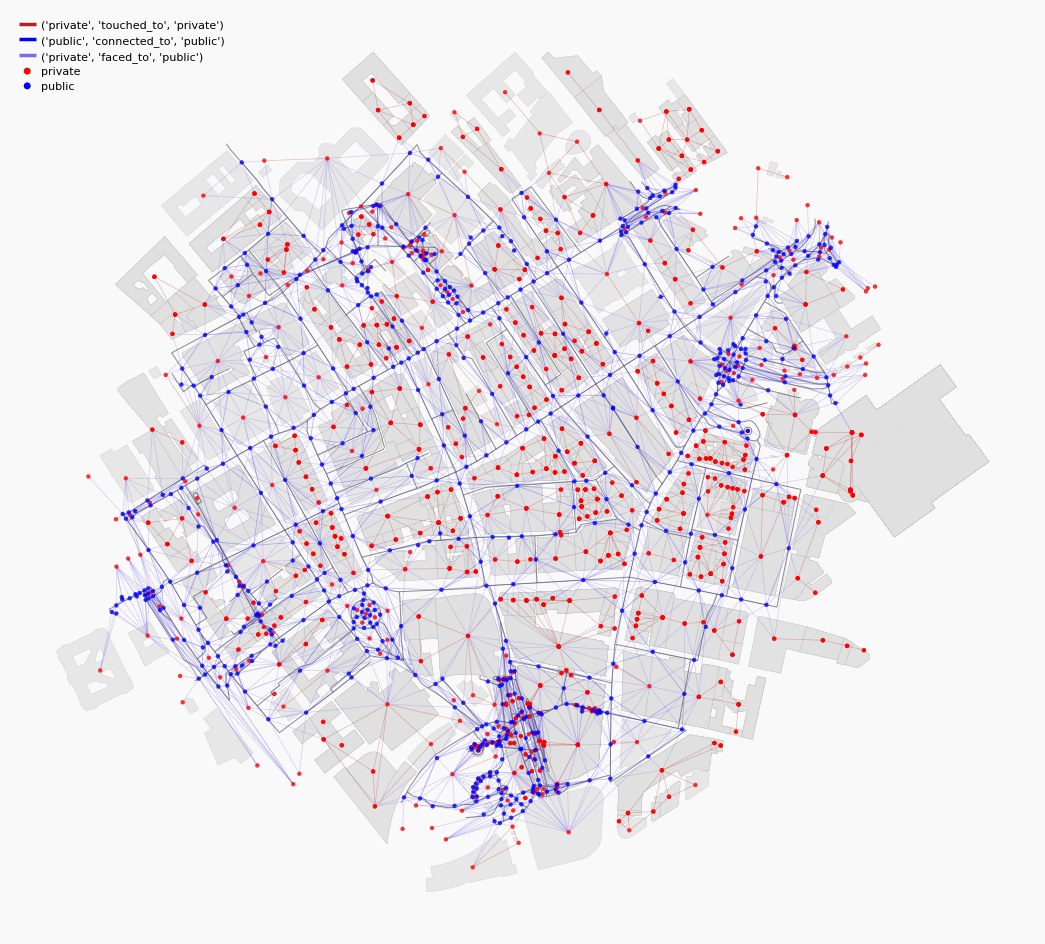

In [35]:
fig, ax = plt.subplots(figsize=(14, 12), facecolor='#f9f9f9')

morpho_nodes["private"]["building_geometry"].plot(ax=ax, color='#e0e0e0', edgecolor='#c0c0c0', linewidth=0.3, alpha=0.7)
morpho_nodes["public"]["segment_geometry"].plot(ax=ax, color='#404040', linewidth=0.7, alpha=0.6)

c2g.plot_graph(
    nodes=morpho_nodes,
    edges=morpho_edges,
    subplots=False,
    ax=ax,
    bgcolor="#f9f9f9",
    labelcolor="#000000",
    node_color={'private': 'red', 'public': 'blue'},
    edge_color={
        ('private', 'touched_to', 'private'): '#B22222',
        ('public', 'connected_to', 'public'): '#0000FF',
        ('private', 'faced_to', 'public'): '#7B68EE',
    },
    markersize=10,
    linewidth=0.2,
)

In [36]:
osm_hetero_data = c2g.gdf_to_pyg(morpho_nodes, morpho_edges)

In [37]:
osm_hetero_data

HeteroData(
  crs=EPSG:27700,
  graph_metadata=<city2graph.base.GraphMetadata object at 0x133001640>,
  private={
    x=[1489, 0],
    pos=[1489, 2],
  },
  public={
    x=[651, 0],
    pos=[651, 2],
  },
  (private, touched_to, private)={
    edge_index=[2, 564],
    edge_attr=[564, 0],
  },
  (public, connected_to, public)={
    edge_index=[2, 1299],
    edge_attr=[1299, 0],
  },
  (private, faced_to, public)={
    edge_index=[2, 3276],
    edge_attr=[3276, 0],
  }
)